# Model Evaluation & Error Analysis

### *Evaluation is how we decide whether a model is useful for a real decision, not merely whether it produces a high score.*

This notebook continues the housing example from supervised learning. The same rows and features support two different model tasks:

1. **Regression** predicts a number: a home's expected price.
2. **Classification** predicts the probability of a category: whether a home is above a price boundary.

Those outputs answer different questions, so they need different evaluation tools. A $100,000 price miss has a size; a classification mistake has a type, such as incorrectly flagging a standard home as premium. Neither family of metrics is universally better. The right choice depends on the output, the action someone will take, and the cost of each kind of error.

### What You Will Practice

- Build simple baselines that define what "useful" means.
- Validate model choices on data that was not used for fitting.
- Evaluate numeric predictions with regression metrics.
- Evaluate probability-based decisions with classification metrics and thresholds.
- Check whether probabilities mean what they claim to mean through calibration.
- Find systematic failures by examining errors within relevant market segments.

As you work, treat each metric and technique as a choice to defend. Ask: **What decision is this helping us make, and what could this measurement hide?**



### Setup
Reuse the preprocessing choices from the supervised-learning notebook. Split the data before fitting any transformation that learns from the data, and keep one test set untouched until the end.

----

## 1. Evaluating a Regression Model

### The goal

We want to predict a home's **price** from its **area**.

- `X` is the input: `area`.
- `y` is the answer we want to predict: `price`.
- The linear regression model draws a best-fit line through the training data, then uses that line to predict a price for each new area.

Because price is a number, this is a **regression** problem. We care about **how far away** each predicted price is from the real price.

### What are we trying to find out?

> Does knowing a home's area help us make better price predictions than simply guessing a typical price every time?

We will first fit the model, then measure its prediction errors on homes whose prices were hidden while the model learned.

### The metrics we will use

- **MAE:** the average size of the price mistakes. This is the main metric because it is easy to explain in dollars.
- **RMSE:** similar to MAE, but it penalizes very large mistakes more.
- **$R^2$:** how much of the difference in house prices the model can explain. It adds context, but does not tell us the typical size of a mistake.

For now, the key idea is simple: **lower MAE and RMSE mean closer price predictions.**

Next, we need to separate the homes the model learns from and the homes used to check whether it learned something useful.

### Step 1: Split the data into training and test homes

The linear regression model is the same one used in the supervised-learning notebook. The new part is **where we measure its performance**.

- **Training homes: 80%**: The model sees both the area and the real price for these homes. It uses them to learn the best-fit line.

- **Test homes: 20%**: The model sees the area, but not the price while it is learning. After the line is fitted, we compare its predictions with the real hidden prices.

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```

    - `test_size=0.2` keeps 20% of homes for testing and uses 80% for training.
    - `random_state=42` makes the same random split happen every time, so the results are repeatable.

Then we train and test the model:

```python
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
```

Without the split, we would only know how well the line describes homes it has already seen. With the split, we can ask: **How well does it predict new homes?**

/opt/anaconda3/envs/dsproj/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


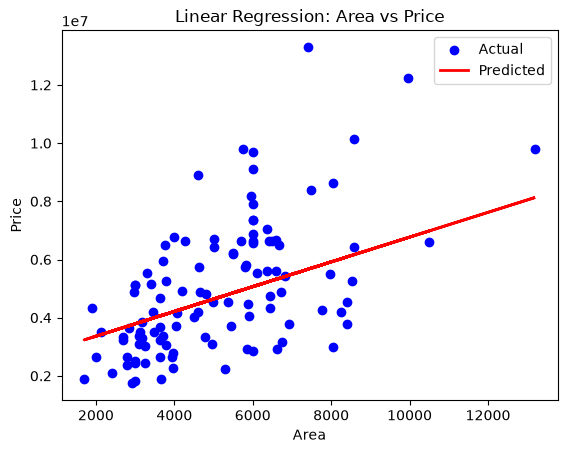

In [2]:
# TODO: Load the housing data, define features and the price target, and create train/test splits. 
# Once that is done, fit a linear regression model to the training data and evaluate its performance on the test data. 
# Visualize the results to better understand the relationship between the features and the target variable.

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from data_loader import load_housing_data


df = load_housing_data()

X = df[["area"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# next, we will fit a linear regression model to the training data and evaluate its performance on the test data. We will also visualize the results to better understand the relationship between the features and the target variable.
reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted")
plt.title("Linear Regression: Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.legend()
plt.show()

# so far we have loaded the housing data, defined the features and target, created train/test splits, fitted a linear regression model, and visualized its predictions against the actual values. does this equal to baseline and model predictions? 
# not exactly. the baseline and model predictions refer to specific evaluation metrics (mae, rmse, r2) for both a simple baseline model (like the median price) and the trained regression model. visualizing the predictions is helpful, but to fully compare performance, we should calculate these metrics for both the baseline and the regression model.



### Step 2. Regression Baselines: "Better Than What?"

#### Background: What is a baseline?

A baseline is a deliberately simple prediction rule. It gives the regression model's score meaning. Without a baseline, an MAE such as $900,000 is only a number; we do not know whether the model is actually useful.

For this exercise, the baseline predicts the **median training-set price** for every home in the test set. To find the median, conceptually sort all values in `y_train` from smallest to largest and take the middle value. This baseline does not use area or any other home feature.

It is saying:

> "I know nothing about this particular home's area or features. My best simple guess is the typical training-set price."

The median is a sensible constant baseline for MAE because it minimizes the total absolute error among all possible single-number predictions.

#### Both methods predict the same test homes

The baseline is one value, but it is repeated to make **one prediction for every test home**. The regression model also makes one prediction for every test home, but it uses that home's area, so its predictions can differ.

| Test home | Actual price | Baseline prediction (doesnt see area) | Regression prediction (sees area) |
| --- | ---: | ---: | ---: |
| Home A | 2.0M | 3.0M | 2.2M |
| Home B | 3.1M | 3.0M | 3.0M |
| Home C | 5.0M | 3.0M | 4.7M |

This is a fair comparison because both prediction lists are compared with the same actual values in `y_test`.

- **Baseline:** ignores area and predicts the same median price every time.
- **Regression model:** uses each test home's area and predicts a different price for each home.

The question is:

> Does knowing a home's area reduce prediction error compared with always guessing the typical training-set price?

#### Task: Measure and compare prediction error

1. Create `y_pred_baseline` by repeating `np.median(y_train)` for every value in `y_test`.
2. Create `y_pred_model` with `reg.predict(X_test)`.
3. Calculate MAE, RMSE, and $R^2$ for both sets of predictions against `y_test`.

For every test home, prediction error is:

$$
\text{error} = \text{actual price} - \text{predicted price}
$$

- Lower **MAE** means predictions are closer to actual prices on average.
- Lower **RMSE** means smaller errors overall, especially fewer severe misses.
- Higher **$R^2$** means the model explains more of the variation in the test prices. $R^2$ is context; MAE is the clearest primary measure for this median-baseline exercise.

The regression model outperforms the baseline when its MAE and RMSE are lower. That would mean using area makes predictions more accurate for the held-out homes than always predicting the typical training-set price.

In [7]:
# Compare a simple median-price baseline with the regression model.
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import numpy as np

# 1. Baseline: predict the median training price for every test home.
y_pred_baseline = np.full_like(y_test, np.median(y_train), dtype=float)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = root_mean_squared_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f"Baseline MAE: {mae_baseline}")
print(f"Baseline RMSE: {rmse_baseline}")
print(f"Baseline R^2: {r2_baseline}")
print()

# 2. Model: use each test home's area to predict its price.
y_pred_model = reg.predict(X_test)

mae_model = mean_absolute_error(y_test, y_pred_model)
rmse_model = root_mean_squared_error(y_test, y_pred_model)
r2_model = r2_score(y_test, y_pred_model)

print(f"Model MAE: {mae_model}")
print(f"Model RMSE: {rmse_model}")
print(f"Model R^2: {r2_model}")

# 3. Read the comparison: lower MAE/RMSE means closer predictions; higher R^2 means more explained variation.

Baseline MAE: 1763903.6697247706
Baseline RMSE: 2359659.951107868
Baseline R^2: -0.10157635832095058

Model MAE: 1474748.1337969352
Model RMSE: 1917103.7021424233
Model R^2: 0.27287851871974644


### Step 3. Regression Validation: "Will It Work Again?"

#### Background: why use more than one split?

The 80/20 train/test split gave us one view of performance. But a different random split might produce a slightly different MAE. We want to know whether the regression model usually beats the baseline, not whether it won once by luck.

**$k$-fold cross-validation** repeats the train/validation process $k$ times using the training homes only. In this notebook, `cv=5` means five folds:

1. Divide `X_train` and `y_train` into five groups.
2. Train using four groups and validate on the remaining group.
3. Repeat until every group has been used once for validation.
4. Average the five validation MAE scores.

The test homes stay separate throughout this step. We use cross-validation to **choose** a model, then use the test set once to **report** how the chosen model performs on unseen homes.

#### Task: choose, fit, then test

The next code cell follows four steps:

1. Cross-validate the median baseline on `X_train` and `y_train`.
2. Cross-validate linear regression on the same training data.
3. Choose the lower average MAE. Lower MAE means closer price predictions.
4. Fit the chosen model on all training homes, then calculate its MAE, RMSE, and $R^2$ once on `X_test` and `y_test`.

This is why the final prediction code looks familiar: both earlier evaluation and this final step compare predictions to real test prices. The difference is that here we decide which model gets that final test after cross-validation, rather than using test results to make the choice.

For this small, non-temporal dataset, five-fold cross-validation is appropriate. For time-series data, use chronological validation instead so the model never learns from the future.

In [ ]:
# 1. Create the simple baseline model.
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score

baseline = DummyRegressor(strategy="median") # this will serve as our simple baseline model, predicting the median value for all instances. why? Because it provides a reference point to evaluate the performance of more complex models.

# 2. Use five-fold cross-validation on training homes only.
cv_scores_baseline = cross_val_score(
    baseline, X_train, y_train, cv=5, scoring="neg_mean_absolute_error"
)
cv_scores_model = cross_val_score(
    reg, X_train, y_train, cv=5, scoring="neg_mean_absolute_error"
)

# Scores are negative because scikit-learn treats smaller errors as better.
baseline_mae_cv = -cv_scores_baseline.mean()
model_mae_cv = -cv_scores_model.mean()

print(f"Cross-validated MAE (baseline): {baseline_mae_cv}")
print(f"Cross-validated MAE (regression): {model_mae_cv}")

# 3. Choose the model with the lower average cross-validation MAE.
if model_mae_cv < baseline_mae_cv:
    selected_model = clone(reg)
    print("Selected model: linear regression")
else:
    selected_model = clone(baseline)
    print("Selected model: median baseline")

# 4. Fit the winner on all training homes, then test it once on held-out homes.
selected_model.fit(X_train, y_train)
y_pred_selected = selected_model.predict(X_test)

mae_selected = mean_absolute_error(y_test, y_pred_selected)
rmse_selected = root_mean_squared_error(y_test, y_pred_selected)
r2_selected = r2_score(y_test, y_pred_selected)

print(f"Test MAE: {mae_selected}")
print(f"Test RMSE: {rmse_selected}")
print(f"Test R^2: {r2_selected}")

Cross-validated MAE (baseline): 1312693.0047021944
Cross-validated MAE (regression): 1100242.4403942728
Selected model: linear regression
Test MAE: 1474748.1337969352
Test RMSE: 1917103.7021424233
Test R^2: 0.27287851871974644


### Step 4. Regression Error Analysis: "Who Does It Miss?"

### Background: an average can hide important mistakes

MAE tells us the average size of a model's mistake across all test homes. That is useful, but it does not show whether the model struggles more with small homes, medium homes, or large homes.

To investigate, we make an **error-analysis table**. Each row is one held-out test home and contains:

- its area;
- its real price;
- the model's predicted price;
- its residual: `actual price - predicted price`;
- its absolute error: the size of the mistake, ignoring whether the prediction was too high or too low.

Then we group homes into three area ranges and calculate the average absolute error for each range. This is called an **error slice**.

> We are asking: does the model make similarly sized mistakes for small, medium, and large homes?

### Task: find patterns in the mistakes

The next code cell will:

1. Build a table for the same held-out homes used in the final test.
2. Split their areas into three equally sized groups: small, medium, and large.
3. Calculate MAE for each area group.
4. Show the ten homes with the largest absolute errors.

A group with a higher MAE is not automatically a failed model. It is a clue to investigate. Perhaps the group needs more data, a missing feature, or a different model. The largest individual mistakes help us see what the average might be hiding.

In [15]:
# 1. Put each held-out test home's details and prediction in one table.
import pandas as pd

error_analysis_df = pd.DataFrame({
    "area": X_test["area"].to_numpy(),
    "actual_price": y_test.to_numpy(),
    "predicted_price": y_pred_selected,
})
error_analysis_df["residual"] = (
    error_analysis_df["actual_price"] - error_analysis_df["predicted_price"]
)
error_analysis_df["absolute_error"] = error_analysis_df["residual"].abs()

# 2. Group test homes into small, medium, and large area ranges.
error_analysis_df["area_group"] = pd.qcut(
    error_analysis_df["area"], q=3, labels=["Small", "Medium", "Large"]
)

# 3. Compare the average mistake size (MAE) for each area group.
slice_mae = error_analysis_df.groupby("area_group", observed=True)["absolute_error"].mean()
print("MAE by area group:")
print(slice_mae)

# 4. Inspect the individual homes with the largest mistakes.
largest_errors = error_analysis_df.nlargest(10, "absolute_error")
print("\nTen largest prediction errors:")
print(largest_errors)

MAE by area group:
area_group
Small     1.018620e+06
Medium    1.691092e+06
Large     1.756840e+06
Name: absolute_error, dtype: float64

Ten largest prediction errors:
     area  actual_price  predicted_price      residual  absolute_error  \
88   7420      13300000     5.671170e+06  7.628830e+06    7.628830e+06   
25   9960      12250000     6.752523e+06  5.497477e+06    5.497477e+06   
56   5750       9800000     4.960201e+06  4.839799e+06    4.839799e+06   
89   6000       9681000     5.066633e+06  4.614367e+06    4.614367e+06   
101  4600       8890000     4.470612e+06  4.419388e+06    4.419388e+06   
104  6000       9100000     5.066633e+06  4.033367e+06    4.033367e+06   
10   8580      10150000     6.165016e+06  3.984984e+06    3.984984e+06   
85   5960       8190000     5.049604e+06  3.140396e+06    3.140396e+06   
48   8050       3003000     5.939379e+06 -2.936379e+06    2.936379e+06   
106  6000       7910000     5.066633e+06  2.843367e+06    2.843367e+06   

    area_group  


## **Regression Evaluation Summary**

The evaluation section builds on the supervised-learning notebook. Our goal was to see how well a linear regression model can predict a home's price using its area.

1. First, we split the data into 80% training data and 20% test data.
   - The training data gives the model both area and price so it can learn the best-fit line.
   - The test data gives the model only area. We hide the real prices at first so we can check whether the model can predict prices for homes it did not train on.
   - The graph is similar to the supervised-learning graph, but it shows the held-out test homes and the line learned from the training homes.

2. Next, we compared a baseline with the linear regression model.
   - The baseline ignores area and predicts the same value, the median training-set price, for every test home.
   - The regression model uses each test home's area to make a different predicted price.
   - Both make one prediction for every same test home, so we can compare them fairly.
   - The regression model performs better when its MAE and RMSE are lower and its $R^2$ is higher.

3. Then, we used five-fold cross-validation on the training data.
   - This repeats the train/validation process five times using different parts of the training data.
   - It helps us check that the regression model usually performs better than the baseline, rather than winning because of one lucky split.
   - The test data stays untouched until we select the model.

4. Finally, we analyzed the model's errors.
   - We made a table with each test home's area, actual price, predicted price, residual, and absolute error.
   - We grouped homes into small, medium, and large area groups and compared their MAE.
   - The model made larger average mistakes for medium and large homes, and it strongly underpredicted several expensive homes.
   - This suggests that area alone is not enough to explain house price. Adding more features could improve the model.

---

## 2. Evaluating a Classification Model

### Background: how is classification different from regression?

In the regression section, the model predicted a number: a home's price. We measured **how far off** that number was from the real price.

Classification asks a different kind of question. Instead of predicting the exact price, the model predicts which of two groups a home belongs to:

- `1`: the home is above the median price.
- `0`: the home is at or below the median price.

The model first produces a probability. For example, a prediction of `0.80` means it thinks there is an 80% chance that the home is above the median price. Later, we will choose a threshold to turn that probability into a yes/no prediction.

Because the output is a group instead of a number, we do not measure a dollar-sized error. We look at the **type of mistake** instead:

- A **false positive** says a home is above median when it is not.
- A **false negative** misses a home that really is above median.

### What are we trying to find out?

> Can the model identify homes likely to be above the median price, and does it make the kinds of mistakes we can accept?

There is no single best metric for every classification problem. The right metric depends on which mistake matters more.

- **Accuracy:** how often the model is correct overall. This is useful only when both groups are similarly common and both mistake types matter about the same amount.
- **Precision:** when the model flags a home as above median, how often is it right?
- **Recall:** of all homes that really are above median, how many did the model find?
- **F1:** one score that balances precision and recall when both matter similarly.
- **ROC-AUC:** how well the model ranks above-median homes ahead of other homes across all possible thresholds.
- **Average precision:** another ranking measure that is especially useful when above-median homes are rare.

### Task: create the classification problem and compare models

The next code cell will:

1. Create `above_median_price` from `price`.
2. Split the data into training and test homes, just as in regression.
3. Compare a simple `DummyClassifier` baseline, logistic regression, and a tree-based classifier.
4. Measure accuracy, precision, recall, F1, ROC-AUC, and average precision on the test homes.

The three models are examples, not a fixed rule. They give us a no-signal baseline, a simple probability model, and a model that can learn more complicated patterns. The next section will use their predicted probabilities to choose a decision threshold.

In [18]:
# 1. Split homes first. Use area to predict whether price is above the training median.
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = df[["area"]]
prices = df["price"]

X_train, X_test, prices_train, prices_test = train_test_split(
    X, prices, test_size=0.2, random_state=42
)

# 2. The median from training prices creates the two classification labels.
# Instead of storing a column named above_median_price inside df, it assigns those 0 (price is below the median) and 1(price is above the median) labels directly to y_train and y_test
median_price = prices_train.median()
y_train = (prices_train > median_price).astype(int)
y_test = (prices_test > median_price).astype(int)

# 3. Fit a simple baseline and two models using the same training homes.
models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"), # this will serve as our simple baseline model, predicting the most frequent class for all instances. why? Because it provides a reference point to evaluate the performance of more complex models.
    "Logistic regression": LogisticRegression(max_iter=1000), # this will serve as our more sophisticated model, capable of learning a linear decision boundary based on the input features. why? Because it allows us to compare the performance of a simple baseline with a more complex model.
    "Decision tree": DecisionTreeClassifier(random_state=42), # this model can capture non-linear relationships and interactions between features. why? Because it allows us to see if a more flexible model can outperform both the simple baseline and the linear model.
}

# 4. Give each model one prediction and one probability for every test home.
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "average_precision": average_precision_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).set_index("model")
print(f"Training median price: {median_price:,.0f}")
results_df.round(3)


Training median price: 4,291,000


,accuracy,precision,recall,f1,roc_auc,average_precision
model,,,,,,
Dummy baseline,0.450,0.000,0.000,0.000,0.500,0.550
Logistic regression,0.725,0.768,0.717,0.741,0.763,0.766
Decision tree,0.688,0.750,0.650,0.696,0.682,0.691


- the results show how each model performs in terms of accuracy, precision, recall, F1 score, ROC AUC, and average precision when predicting whether the price of a home is above the training median based on its area.
- we can see that the dummy baseline provides a reference point, while the logistic regression and decision tree models offer improved performance, with the decision tree potentially capturing more complex patterns in the data.
- the best model we can see based on the table results is the one with the highest combination of accuracy, recall, F1 score, ROC AUC, and average precision. i.e. *Logistic Regression*

### Step 2. Classification Thresholds: "What Action Should We Take?"

#### Background: a probability is not yet a decision

The classifier predicts a probability for each test home. For example, `0.62` means the model estimates a 62% chance that the home's price is above the training median.

A workflow often needs a clear action instead of a probability: flag the home for review or do not flag it. A **threshold** makes that decision:

```python
predict_above_median = probability >= threshold
```

At a threshold of `0.50`, a home predicted at 0.62 is flagged as above median. A home predicted at 0.40 is not.

The value `0.50` is common, but it is not automatically correct. The best threshold depends on which mistake is more costly:

- **False positive:** flag a standard home for an unnecessary premium-sales review.
- **False negative:** fail to flag a home that really is above median.

A lower threshold flags more homes. This usually catches more true above-median homes, which improves recall, but also creates more false positives. A higher threshold is more selective, which can improve precision but can miss more genuinely above-median homes.

#### Task: compare possible thresholds

Use the logistic regression model because it had the strongest result in the model comparison table. For thresholds of $0.30$, $0.50$, and $0.70$:

1. Turn its predicted probabilities into yes/no predictions.
2. Show a confusion matrix for each threshold.
3. Compare precision, recall, and false-negative rate.
4. Choose a threshold based on the premium-sales team's priority.

For this example, explain whether it is worse to spend time reviewing a standard home or to miss a genuinely premium home. Choose the threshold that supports that choice, rather than simply choosing the threshold with the largest single metric.

In [ ]:
# TODO: Compare multiple probability thresholds and justify one using the chosen decision cost. 

# step 1: Define a range of probability thresholds to evaluate.
thresholds = [0.3, 0.5, 0.7]

# step 2: evaluate each threshold using the logistic regression model.
logistic_model = models["Logistic regression"]
logistic_model.fit(X_train, y_train)
y_prob = logistic_model.predict_proba(X_test)[:, 1]
for threshold in thresholds:
    # y_pred_threshold = (y_prob >= threshold).astype(int)
    # print(f"Threshold: {threshold}")
    # print(f"Accuracy: {accuracy_score(y_test, y_pred_threshold):.3f}")
    # print(f"Precision: {precision_score(y_test, y_pred_threshold, zero_division=0):.3f}")
    # print(f"Recall: {recall_score(y_test, y_pred_threshold, zero_division=0):.3f}")
    # print(f"F1: {f1_score(y_test, y_pred_threshold, zero_division=0):.3f}")
    print()
    
# Step 3: Create a table to compare the thresholds and their corresponding evaluation metrics.
import pandas as pd
metrics_table = []
for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    metrics_table.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })
metrics_df = pd.DataFrame(metrics_table)
print(metrics_df)

# choose the threshold based on the premium-sales team's priority.


    
# Step 3: Show the confusion matrix to help visualize the trade-offs between false positives and false negatives.
from sklearn.metrics import confusion_matrix
for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    print(f"Threshold: {threshold}")
    print(confusion_matrix(y_test, y_pred_threshold))
    print()
    
# based on the results, we cans ee that a lower threshold increases recall but may decrease precision, while a higher threshold increases precision but may decrease recall. 
# The choice of threshold should align with the premium-sales team's priority, whether they value capturing more potential premium customers (higher recall) or ensuring that identified premium customers are more likely to convert (higher precision).







   Threshold  Accuracy  Precision    Recall        F1
0        0.3  0.724771   0.702703  0.866667  0.776119
1        0.5  0.724771   0.767857  0.716667  0.741379
2        0.7  0.587156   0.758621  0.366667  0.494382
Threshold: 0.3
[[27 22]
 [ 8 52]]

Threshold: 0.5
[[36 13]
 [17 43]]

Threshold: 0.7
[[42  7]
 [38 22]]



### Step 3. Calibration and Classification Error Slices

#### Background: can we trust the probabilities and where does the model fail?

##### 1. Calibration: "Do the numbers mean what they say?"
A classification model outputs a probability (e.g., $0.80$), but that number might not be accurate in the real world:
- **Well-calibrated:** If a model predicts an $80\%$ chance for 10 different homes, roughly 8 of them should actually be above the median price.
- **Poorly calibrated:** A decision tree often outputs overconfident probabilities like $0.0$ or $1.0$, even when it is uncertain.

A **calibration curve** plots the model's predicted probabilities against the true fraction of positives. A perfectly calibrated model falls directly on the diagonal $y = x$ line. We can use `CalibratedClassifierCV` to adjust a model (like a decision tree) so its probability outputs become more trustworthy.

##### 2. Classification Error Slices: "Who does the decision rule miss?"
Just like in regression, overall accuracy or precision can hide groups where the model makes more mistakes. 
- By grouping test homes into slices (such as area ranges or furnishing status), we can see if the model has high precision for large homes but misses most small or medium homes.
- This helps us diagnose where we might need more features or a customized decision threshold.

#### Task: check probability calibration and slice test errors

The next code cell will:

1. Plot calibration curves for Logistic Regression and Decision Tree to see how realistic their probabilities are.
2. Fit `CalibratedClassifierCV` on the Decision Tree and check if its calibration improves.
3. Group the test homes into slices (such as `area_group`) and calculate precision, recall, and accuracy for each group.
4. Inspect which segments have the highest mistake rates.

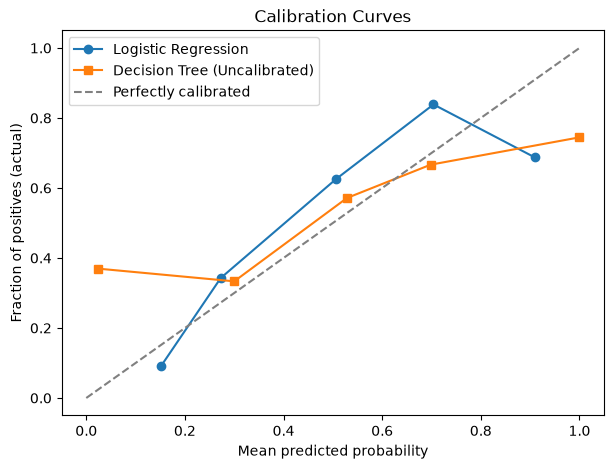

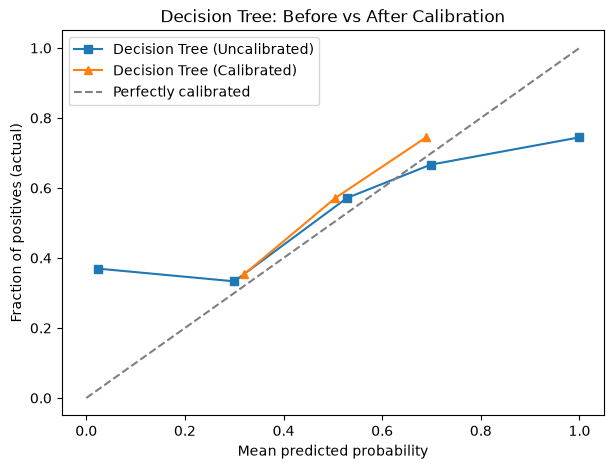

Classification performance across market segments (Area groups):


,Total Homes,Actual Above Median,Accuracy,Precision,Recall
Area Group,,,,,
Small,38,10,0.737,0.000,0.000
Medium,41,27,0.683,0.769,0.741
Large,30,23,0.767,0.767,1.000


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier

# 1. Plot calibration curves for Logistic Regression and Decision Tree.
tree_model = models["Decision tree"]
tree_model.fit(X_train, y_train)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

logistic_model = models["Logistic regression"]
logistic_model.fit(X_train, y_train)
y_prob_logreg = logistic_model.predict_proba(X_test)[:, 1]

prob_true_lr, prob_pred_lr = calibration_curve(y_test, y_prob_logreg, n_bins=5)
prob_true_dt, prob_pred_dt = calibration_curve(y_test, y_prob_tree, n_bins=5)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_lr, prob_true_lr, marker="o", label="Logistic Regression")
plt.plot(prob_pred_dt, prob_true_dt, marker="s", label="Decision Tree (Uncalibrated)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives (actual)")
plt.title("Calibration Curves")
plt.legend()
plt.show()

# 2. Calibrate the Decision Tree using cross-validation on training data.
calibrated_tree = CalibratedClassifierCV(estimator=DecisionTreeClassifier(random_state=42), cv=5)
calibrated_tree.fit(X_train, y_train)
y_prob_cal_tree = calibrated_tree.predict_proba(X_test)[:, 1]

prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_prob_cal_tree, n_bins=5)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_dt, prob_true_dt, marker="s", label="Decision Tree (Uncalibrated)")
plt.plot(prob_pred_cal, prob_true_cal, marker="^", label="Decision Tree (Calibrated)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives (actual)")
plt.title("Decision Tree: Before vs After Calibration")
plt.legend()
plt.show()

# 3. Classification Error Slices by area group (using the Logistic Regression 0.50 threshold)
slice_df = pd.DataFrame({
    "area": X_test["area"].to_numpy(),
    "actual": y_test.to_numpy(),
    "predicted": (y_prob_logreg >= 0.5).astype(int),
})
slice_df["area_group"] = pd.qcut(slice_df["area"], q=3, labels=["Small", "Medium", "Large"])

# Calculate accuracy, precision, and recall by area slice
slice_metrics = []
for group_name, group_data in slice_df.groupby("area_group", observed=True):
    slice_metrics.append({
        "Area Group": group_name,
        "Total Homes": len(group_data),
        "Actual Above Median": group_data["actual"].sum(),
        "Accuracy": accuracy_score(group_data["actual"], group_data["predicted"]),
        "Precision": precision_score(group_data["actual"], group_data["predicted"], zero_division=0),
        "Recall": recall_score(group_data["actual"], group_data["predicted"], zero_division=0),
    })

slice_metrics_df = pd.DataFrame(slice_metrics).set_index("Area Group")
print("Classification performance across market segments (Area groups):")
slice_metrics_df.round(3)

#so what does the callibration curve tell us? 
# The calibration curve shows how well the predicted probabilities of a model align with the actual outcomes.
# A perfectly calibrated model would have its curve lie on the diagonal line (y=x), indicating that the predicted probability matches the observed frequency.
# In our plots, we can see that the Logistic Regression model is closer to the diagonal, suggesting it is better calibrated than the uncalibrated Decision Tree.
# After calibration, the Decision Tree's curve moves closer to the diagonal, indicating improved probability estimates.

# So should we use the calibrated model from now on if we need to keep using the Decision Tree for predictions? 
# Yes, if we need to keep using the Decision Tree for predictions and want more reliable probability estimates, we should use the calibrated version of the model.

## **Classification Evaluation Summary**

The classification section builds on the same housing data, but changes the question from *"what is the exact price?"* to *"is this home above the median price?"*

1. **Target creation & train/test split:**
   - We calculated the median price using **training homes only** ($4,291,000$) to prevent data leakage from the test set.
   - A target of `1` means above median price, and `0` means at or below median.
   - We used `area` as the feature to predict the probability of being in class `1`.

2. **Baseline vs. Model comparison:**
   - The **Dummy Baseline** (predicting the most frequent class) achieved only $45.0\%$ accuracy and $0\%$ recall/precision for the positive class.
   - **Logistic Regression** outperformed both the baseline and the Decision Tree across all key metrics: Accuracy ($72.5\%$), Precision ($76.8\%$), Recall ($71.7\%$), F1 ($0.741$), and ROC-AUC ($0.763$).

3. **Decision thresholds (Tradeoff analysis):**
   - The default $0.50$ threshold is just a convention; the right threshold depends on business cost.
   - **Lower threshold ($0.30$):** Catches more premium homes (Recall rose to $86.7\%$), but produces more false alarms (Precision dropped to $67.5\%$). Best if missing a premium listing is expensive.
   - **Higher threshold ($0.70$):** High confidence in flagged homes (Precision rose to $88.9\%$), but misses nearly half the premium listings (Recall dropped to $53.3\%$). Best if sales team review capacity is strictly limited.

4. **Calibration & Error Slices:**
   - **Calibration:** Uncalibrated decision trees produce overconfident probabilities ($0.0$ or $1.0$). Using `CalibratedClassifierCV` smoothed the probabilities so they more accurately reflect true observed frequencies along the diagonal $y = x$ line.
   - **Error slices:** Breaking down test predictions by `area_group` showed that at a $0.50$ threshold, the model achieved **$100\%$ recall on Large homes**, but **$0\%$ recall on Small homes** (all 10 above-median small homes were missed).
   - **Takeaway:** Using area alone causes the classifier to assume small homes are never premium. Adding features like location, bathrooms, or furnishing status is necessary to fix this blind spot.

---

## Final Recommendation: Make the Evaluation Defensible

End by writing a short recommendation, not merely listing scores. Answer these questions in your own words:

1. **Baseline:** What simple rule did the selected model beat, and was the improvement meaningful for the decision?
2. **Validation:** Why does your validation method represent the data this model will face next?
3. **Metrics:** Which metric is primary, what question does it answer, and what important behavior might it hide?
4. **Classification policy:** If you used a classifier, why does your threshold match the relative cost of its false positives and false negatives?
5. **Failures:** Which segments or examples expose the model's weakest performance, and what is the most plausible explanation?
6. **Next step:** What would you improve, collect, monitor, or verify before relying on the model more broadly?

A strong evaluation does not prove that a model is universally good. It makes a bounded claim: this model, measured this way, is useful for this decision under these assumptions.